In [49]:
# Célula 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🎯 BASELINE MODEL - LOGISTIC REGRESSION")
print("=" * 80)
print("\n💡 Por que começar com Logistic Regression?")
print("   • Simples e interpretável")
print("   • Rápido de treinar")
print("   • Estabelece baseline de performance")
print("   • Funciona bem com dados padronizados")

🎯 BASELINE MODEL - LOGISTIC REGRESSION

💡 Por que começar com Logistic Regression?
   • Simples e interpretável
   • Rápido de treinar
   • Estabelece baseline de performance
   • Funciona bem com dados padronizados


In [54]:
import joblib

# Carregar splits
splits = joblib.load("../data/final/splits.pkl")

# Escolher versão
version = "standardized"   # ou "no_scale", "normalized"

X_train = splits[version]["X_train"]
X_test  = splits[version]["X_test"]
y_train = splits[version]["y_train"]
y_test  = splits[version]["y_test"]

print(f"Train: {len(X_train)} {len(y_train)}")
print(f"Test:  {len(X_test)} {len(y_test)}")


Train: 119387 119387
Test:  29847 29847


In [57]:
print(X_train.isna().sum().sum(), X_test.isna().sum().sum())
from sklearn.impute import SimpleImputer

# Criar imputador (substitui NaN pela média da coluna)
imputer = SimpleImputer(strategy="median")

# Ajustar no treino e transformar
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transformar o teste com os mesmos parâmetros
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Checar novamente se ainda existem NaNs
print("NaNs após imputação:")
print(X_train.isna().sum().sum(), X_test.isna().sum().sum())


78599 19646
NaNs após imputação:
0 0


In [58]:
# Célula 3: Treinar Modelo Baseline
print("\n" + "=" * 80)
print("🔄 TREINANDO LOGISTIC REGRESSION")
print("=" * 80)

# Criar modelo
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced'  # Ajuda com desbalanceamento residual
)

print("\n⏳ Treinando modelo...")
lr_model.fit(X_train, y_train)
print("✅ Modelo treinado!")

# Fazer predições
print("\n🔮 Fazendo predições...")
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

y_pred_proba_train = lr_model.predict_proba(X_train)[:, 1]
y_pred_proba_test = lr_model.predict_proba(X_test)[:, 1]

print("✅ Predições concluídas!")


🔄 TREINANDO LOGISTIC REGRESSION

⏳ Treinando modelo...
✅ Modelo treinado!

🔮 Fazendo predições...
✅ Predições concluídas!


In [59]:
# verificando dados (estava gerando erro no evaluate porque y_test não estava binario e tinha valores NaN)
print("y_test shape:", len(y_test))
print("y_pred_test shape:", len(y_pred_test))
print("y_pred_proba_test shape:", y_pred_proba_test.shape)
print("Valores únicos em y_test:", pd.Series(y_test).unique())


y_test shape: 29847
y_pred_test shape: 29847
y_pred_proba_test shape: (29847,)
Valores únicos em y_test: [False  True]


In [62]:
def evaluate_model(y_true, y_pred, y_pred_proba, dataset_name=""):
    """Função para avaliar modelo"""
    
    # Converter para Series inteiras
    y_true = pd.Series(y_true).astype(int)
    y_pred = pd.Series(y_pred).astype(int)
    
    # Se probabilidades têm duas colunas, pegar só a da classe positiva
    if y_pred_proba.ndim > 1:
        y_pred_proba = y_pred_proba[:, 1]
    
    print(f"\n{'='*80}")
    print(f"📊 {dataset_name}")
    print(f"{'='*80}")
    
    # Métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n🎯 Métricas Gerais:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   AUC-ROC:   {auc:.4f}")
    
    # Classification Report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, 
                                target_names=['Bom Pagador', 'Inadimplente'],
                                digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🧮 Confusion Matrix:\n{cm}")
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm
    }


In [63]:
train_metrics = evaluate_model(y_train, y_pred_train, y_pred_proba_train, "TRAIN SET")
test_metrics  = evaluate_model(y_test, y_pred_test, y_pred_proba_test, "TEST SET")



📊 TRAIN SET

🎯 Métricas Gerais:
   Accuracy:  0.9331 (93.31%)
   F1-Score:  0.0235
   AUC-ROC:   0.7105

📋 Classification Report:
              precision    recall  f1-score   support

 Bom Pagador     0.9336    0.9993    0.9654    111381
Inadimplente     0.5614    0.0120    0.0235      8006

    accuracy                         0.9331    119387
   macro avg     0.7475    0.5057    0.4944    119387
weighted avg     0.9087    0.9331    0.9022    119387


🧮 Confusion Matrix:
[[111306     75]
 [  7910     96]]

📊 TEST SET

🎯 Métricas Gerais:
   Accuracy:  0.9336 (93.36%)
   F1-Score:  0.0351
   AUC-ROC:   0.7184

📋 Classification Report:
              precision    recall  f1-score   support

 Bom Pagador     0.9340    0.9994    0.9656     27845
Inadimplente     0.6923    0.0180    0.0351      2002

    accuracy                         0.9336     29847
   macro avg     0.8132    0.5087    0.5003     29847
weighted avg     0.9178    0.9336    0.9032     29847


🧮 Confusion Matrix:
[[27829 


📊 TRAIN SET

🎯 Métricas Gerais:
   Accuracy:  0.9331 (93.31%)
   F1-Score:  0.0235
   AUC-ROC:   0.7105

📋 Classification Report:
              precision    recall  f1-score   support

 Bom Pagador     0.9336    0.9993    0.9654    111381
Inadimplente     0.5614    0.0120    0.0235      8006

    accuracy                         0.9331    119387
   macro avg     0.7475    0.5057    0.4944    119387
weighted avg     0.9087    0.9331    0.9022    119387


🧮 Confusion Matrix:
[[111306     75]
 [  7910     96]]

📊 TEST SET

🎯 Métricas Gerais:
   Accuracy:  0.9336 (93.36%)
   F1-Score:  0.0351
   AUC-ROC:   0.7184

📋 Classification Report:
              precision    recall  f1-score   support

 Bom Pagador     0.9340    0.9994    0.9656     27845
Inadimplente     0.6923    0.0180    0.0351      2002

    accuracy                         0.9336     29847
   macro avg     0.8132    0.5087    0.5003     29847
weighted avg     0.9178    0.9336    0.9032     29847


🧮 Confusion Matrix:
[[27829 

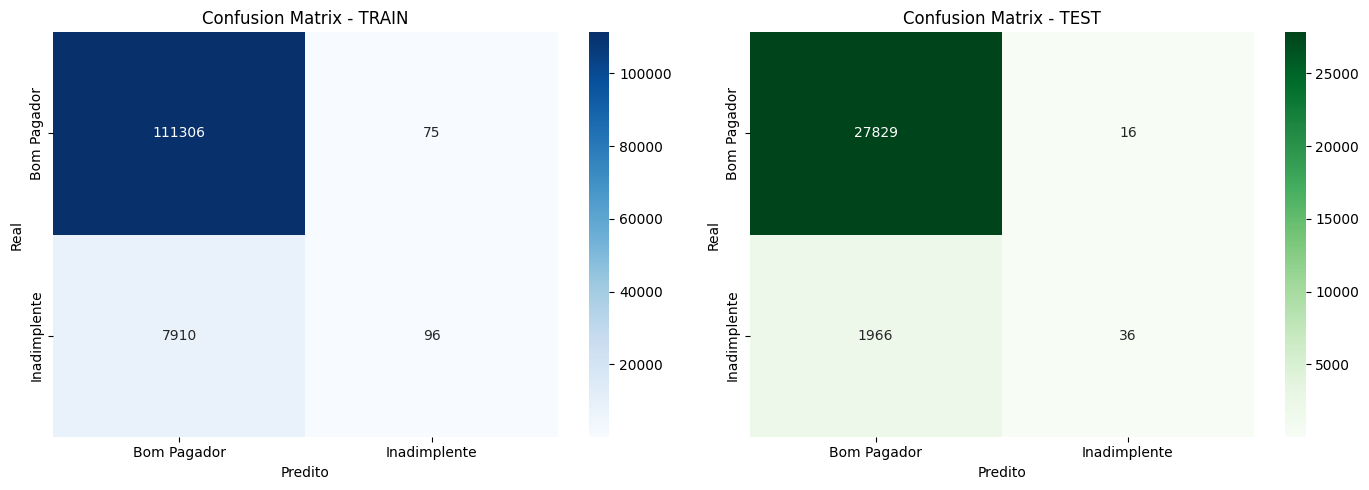


📊 Análise Detalhada (TEST):
   True Negatives (TN):  27,829 - Bons corretamente identificados
   False Positives (FP): 16 - Bons classificados como Maus
   False Negatives (FN): 1,966 - Maus classificados como Bons ⚠️
   True Positives (TP):  36 - Maus corretamente identificados

💰 Impacto de Negócio:
   • 1,966 inadimplentes não detectados (PERDA)
   • 16 bons clientes rejeitados (OPORTUNIDADE PERDIDA)
   • 36 inadimplentes detectados (ECONOMIA)


In [64]:
#Instanciar e treinar o modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

#Gerar previsões e probabilidades
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_pred_proba_train = model.predict_proba(X_train)
y_pred_proba_test = model.predict_proba(X_test)

#Avaliar com a função evaluate_model
train_metrics = evaluate_model(y_train, y_pred_train, y_pred_proba_train, "TRAIN SET")
test_metrics = evaluate_model(y_test, y_pred_test, y_pred_proba_test, "TEST SET")

print("\n" + "=" * 80)
print("📊 CONFUSION MATRIX")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
cm_train = train_metrics['confusion_matrix']
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bom Pagador', 'Inadimplente'],
            yticklabels=['Bom Pagador', 'Inadimplente'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - TRAIN')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Test
cm_test = test_metrics['confusion_matrix']
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bom Pagador', 'Inadimplente'],
            yticklabels=['Bom Pagador', 'Inadimplente'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - TEST')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.tight_layout()
plt.show()

# Métricas detalhadas do TEST
tn, fp, fn, tp = cm_test.ravel()
print(f"\n📊 Análise Detalhada (TEST):")
print(f"   True Negatives (TN):  {tn:,} - Bons corretamente identificados")
print(f"   False Positives (FP): {fp:,} - Bons classificados como Maus")
print(f"   False Negatives (FN): {fn:,} - Maus classificados como Bons ⚠️")
print(f"   True Positives (TP):  {tp:,} - Maus corretamente identificados")

print(f"\n💰 Impacto de Negócio:")
print(f"   • {fn:,} inadimplentes não detectados (PERDA)")
print(f"   • {fp:,} bons clientes rejeitados (OPORTUNIDADE PERDIDA)")
print(f"   • {tp:,} inadimplentes detectados (ECONOMIA)")



📈 ROC CURVE


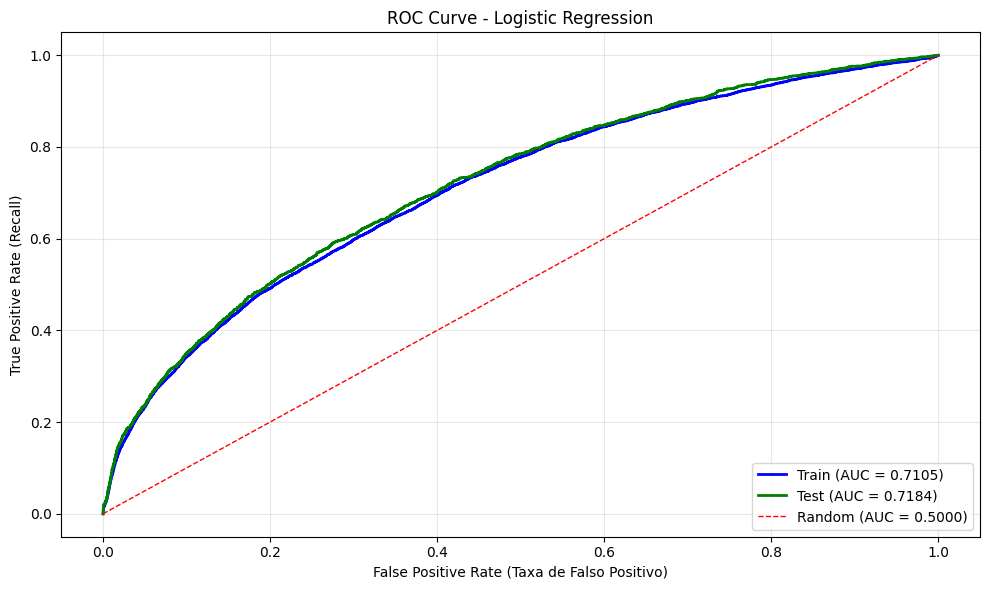


📊 Interpretação do AUC:
   AUC = 0.7184
   👍 Aceitável. Modelo razoável


In [67]:
# Célula 6: ROC Curve
print("\n" + "=" * 80)
print("📈 ROC CURVE")
print("=" * 80)

# Calcular ROC (usando apenas probabilidade da classe positiva)
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train[:, 1])
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test[:, 1])

# Plotar
plt.figure(figsize=(10, 6))

plt.plot(fpr_train, tpr_train, 'b-', 
         label=f'Train (AUC = {train_metrics["auc"]:.4f})', linewidth=2)
plt.plot(fpr_test, tpr_test, 'g-', 
         label=f'Test (AUC = {test_metrics["auc"]:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', 
         label='Random (AUC = 0.5000)', linewidth=1)

plt.xlabel('False Positive Rate (Taxa de Falso Positivo)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Interpretação do AUC:")
print(f"   AUC = {test_metrics['auc']:.4f}")

if test_metrics['auc'] >= 0.9:
    interpretation = "🌟 Excelente! Modelo muito discriminativo"
elif test_metrics['auc'] >= 0.8:
    interpretation = "✅ Muito Bom! Boa capacidade de discriminação"
elif test_metrics['auc'] >= 0.7:
    interpretation = "👍 Aceitável. Modelo razoável"
elif test_metrics['auc'] >= 0.6:
    interpretation = "⚠️ Fraco. Pouco melhor que aleatório"
else:
    interpretation = "❌ Ruim. Quase aleatório"

print(f"   {interpretation}")



📈 PRECISION-RECALL CURVE


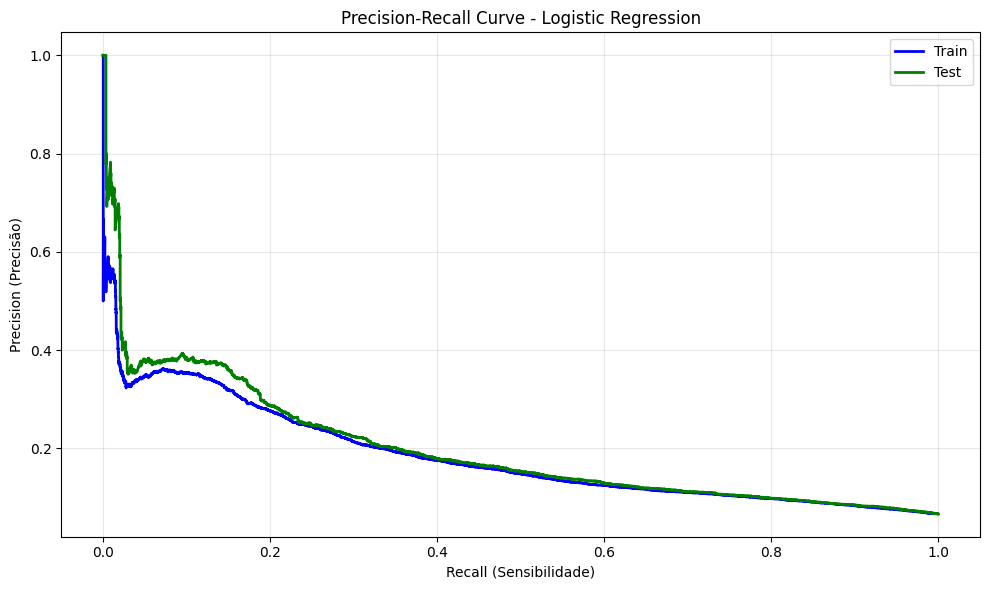


💡 Por que Precision-Recall é importante?
   • Em datasets desbalanceados, é mais informativo que ROC
   • Mostra trade-off entre detectar inadimplentes (recall) e evitar falsos alarmes (precision)


In [68]:
# Célula 7: Precision-Recall Curve
print("\n" + "=" * 80)
print("📈 PRECISION-RECALL CURVE")
print("=" * 80)

from sklearn.metrics import precision_recall_curve

# Calcular Precision-Recall (usando apenas probabilidade da classe positiva)
precision_train, recall_train, thresholds_train = precision_recall_curve(y_train, y_pred_proba_train[:, 1])
precision_test, recall_test, thresholds_test = precision_recall_curve(y_test, y_pred_proba_test[:, 1])

# Plotar
plt.figure(figsize=(10, 6))

plt.plot(recall_train, precision_train, 'b-', label='Train', linewidth=2)
plt.plot(recall_test, precision_test, 'g-', label='Test', linewidth=2)

plt.xlabel('Recall (Sensibilidade)')
plt.ylabel('Precision (Precisão)')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 Por que Precision-Recall é importante?")
print(f"   • Em datasets desbalanceados, é mais informativo que ROC")
print(f"   • Mostra trade-off entre detectar inadimplentes (recall) e evitar falsos alarmes (precision)")


- complementar essa curva com um gráfico de F1 vs Threshold. Assim você consegue visualizar em qual ponto de corte o modelo equilibra melhor precisão e recall para a classe positiva.


📊 F1-SCORE VS THRESHOLD


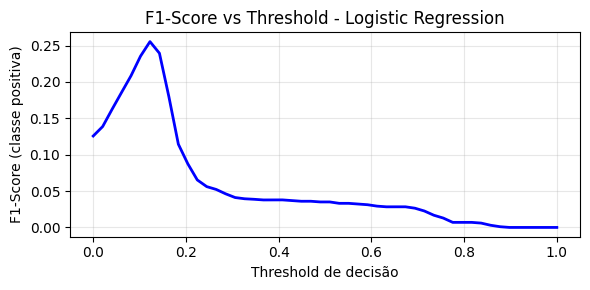


🏆 Melhor Threshold: 0.12
   F1-Score máximo: 0.2555


In [72]:
# Célula 8: F1-Score vs Threshold
print("\n" + "=" * 80)
print("📊 F1-SCORE VS THRESHOLD")
print("=" * 80)

from sklearn.metrics import f1_score

# Usar apenas probabilidade da classe positiva
probas_test = y_pred_proba_test[:, 1]

thresholds = np.linspace(0.0, 1.0, 50)  # 50 pontos entre 0 e 1
f1_scores = []

for t in thresholds:
    y_pred_thresh = (probas_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# Plotar
plt.figure(figsize=(6, 3))
plt.plot(thresholds, f1_scores, 'b-', linewidth=2)
plt.xlabel("Threshold de decisão")
plt.ylabel("F1-Score (classe positiva)")
plt.title("F1-Score vs Threshold - Logistic Regression")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Melhor threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\n🏆 Melhor Threshold: {best_threshold:.2f}")
print(f"   F1-Score máximo: {best_f1:.4f}")



🎚️ ANÁLISE DE THRESHOLD ÓTIMO


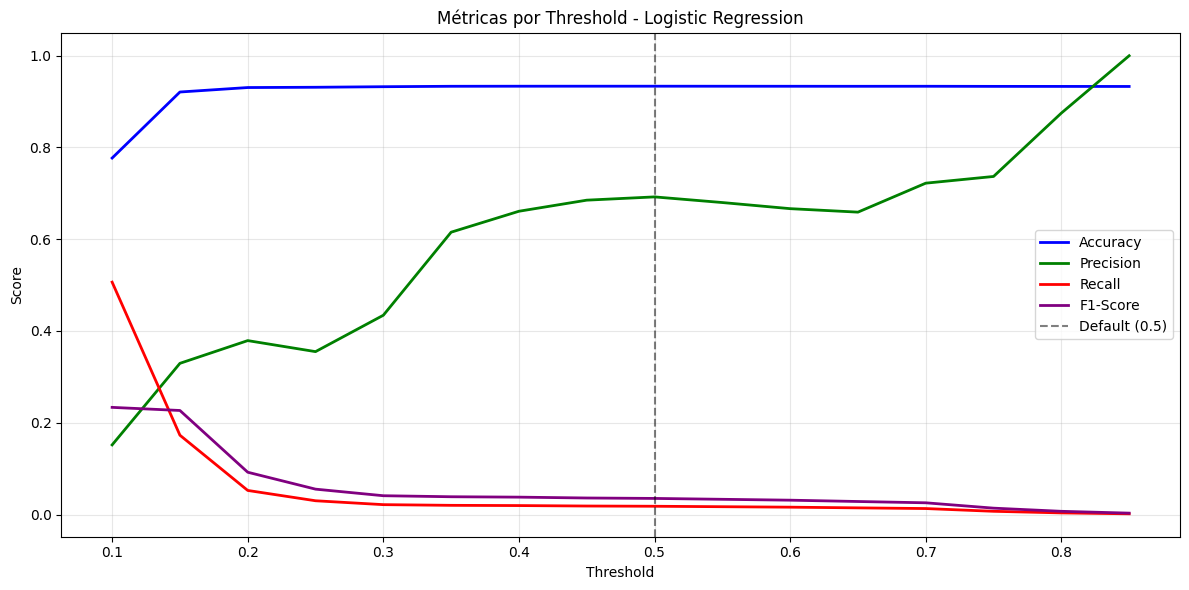


🎯 Threshold Ótimo (máximo F1):
   Threshold: 0.10
   F1-Score: 0.2335
   Accuracy: 0.7770
   Precision: 0.1518
   Recall: 0.5065


In [83]:
# Célula 9: Análise de Threshold
print("\n" + "=" * 80)
print("🎚️ ANÁLISE DE THRESHOLD ÓTIMO")
print("=" * 80)

from sklearn.metrics import precision_recall_fscore_support

# Usar apenas probabilidade da classe positiva
probas_test = y_pred_proba_test[:, 1]

# Testar diferentes thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_threshold = (probas_test >= threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_recall_fscore_support(y_test, y_pred_threshold, average='binary')[0]
    recall = precision_recall_fscore_support(y_test, y_pred_threshold, average='binary')[1]
    f1 = f1_score(y_test, y_pred_threshold)
    
    metrics_by_threshold.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

threshold_df = pd.DataFrame(metrics_by_threshold)

# Plotar métricas por threshold
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_df['threshold'], threshold_df['accuracy'], 'b-', label='Accuracy', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['precision'], 'g-', label='Precision', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['recall'], 'r-', label='Recall', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['f1'], 'purple', label='F1-Score', linewidth=2)

ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Métricas por Threshold - Logistic Regression')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Encontrar threshold ótimo (F1 máximo)
optimal_idx = threshold_df['f1'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'threshold']
optimal_f1 = threshold_df.loc[optimal_idx, 'f1']
# Threshold ótimo pela análise estatística (F1 máximo)
optimal_threshold_f1 = threshold_df['threshold'][threshold_df['f1'].idxmax()]
print(f"\n🎯 Threshold Ótimo (máximo F1):")
print(f"   Threshold: {optimal_threshold:.2f}")
print(f"   F1-Score: {optimal_f1:.4f}")
print(f"   Accuracy: {threshold_df.loc[optimal_idx, 'accuracy']:.4f}")
print(f"   Precision: {threshold_df.loc[optimal_idx, 'precision']:.4f}")
print(f"   Recall: {threshold_df.loc[optimal_idx, 'recall']:.4f}")


In [85]:
# Célula 10: Simulação de Impacto Financeiro
print("\n" + "=" * 80)
print("💰 SIMULAÇÃO DE IMPACTO FINANCEIRO")
print("=" * 80)

# Definir valores médios de negócio (hipotéticos)
lucro_bom_cliente = 1000   # Receita média por bom cliente aprovado
perda_inadimplente = 5000 # Prejuízo médio por inadimplente aprovado

# Usar apenas probabilidade da classe positiva
probas_test = y_pred_proba_test[:, 1]

thresholds = np.arange(0.1, 0.9, 0.1)
impacto_financeiro = []

for threshold in thresholds:
    y_pred_threshold = (probas_test >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    tn, fp, fn, tp = cm.ravel()
    
    # Impacto financeiro
    perdas = tp * 0 + fn * perda_inadimplente   # inadimplentes aprovados (FN)
    oportunidades_perdidas = fp * lucro_bom_cliente  # bons recusados (FP)
    economia = tp * perda_inadimplente          # inadimplentes detectados (TP)
    receita = tn * lucro_bom_cliente            # bons aprovados (TN)
    
    impacto_financeiro.append({
        'threshold': threshold,
        'bons_aprovados': tn,
        'bons_recusados': fp,
        'inadimplentes_aprovados': fn,
        'inadimplentes_detectados': tp,
        'receita': receita,
        'perdas': perdas,
        'oportunidades_perdidas': oportunidades_perdidas,
        'economia': economia,
        'resultado_liquido': receita - perdas - oportunidades_perdidas
    })

impacto_df = pd.DataFrame(impacto_financeiro)

# Mostrar tabela
print("\n📊 Impacto Financeiro por Threshold:")
print(impacto_df[['threshold','bons_aprovados','bons_recusados',
                  'inadimplentes_aprovados','inadimplentes_detectados',
                  'receita','perdas','oportunidades_perdidas','resultado_liquido']])

# Melhor threshold pelo resultado líquido
best_idx = impacto_df['resultado_liquido'].idxmax()
best_threshold = impacto_df.loc[best_idx, 'threshold']
best_resultado = impacto_df.loc[best_idx, 'resultado_liquido']


# Threshold ótimo pela análise financeira (resultado líquido máximo)
optimal_threshold_financeiro = impacto_df['threshold'][impacto_df['resultado_liquido'].idxmax()]

print(f"\n🏆 Threshold Ótimo (máximo resultado líquido): {best_threshold:.2f}")
print(f"   Resultado Líquido: R$ {best_resultado:,.2f}")



💰 SIMULAÇÃO DE IMPACTO FINANCEIRO

📊 Impacto Financeiro por Threshold:
   threshold  bons_aprovados  bons_recusados  inadimplentes_aprovados  \
0        0.1           22177            5668                      988   
1        0.2           27673             172                     1897   
2        0.3           27789              56                     1959   
3        0.4           27825              20                     1963   
4        0.5           27829              16                     1966   
5        0.6           27829              16                     1970   
6        0.7           27835              10                     1976   
7        0.8           27844               1                     1995   

   inadimplentes_detectados   receita   perdas  oportunidades_perdidas  \
0                      1014  22177000  4940000                 5668000   
1                       105  27673000  9485000                  172000   
2                        43  27789000  9795000  

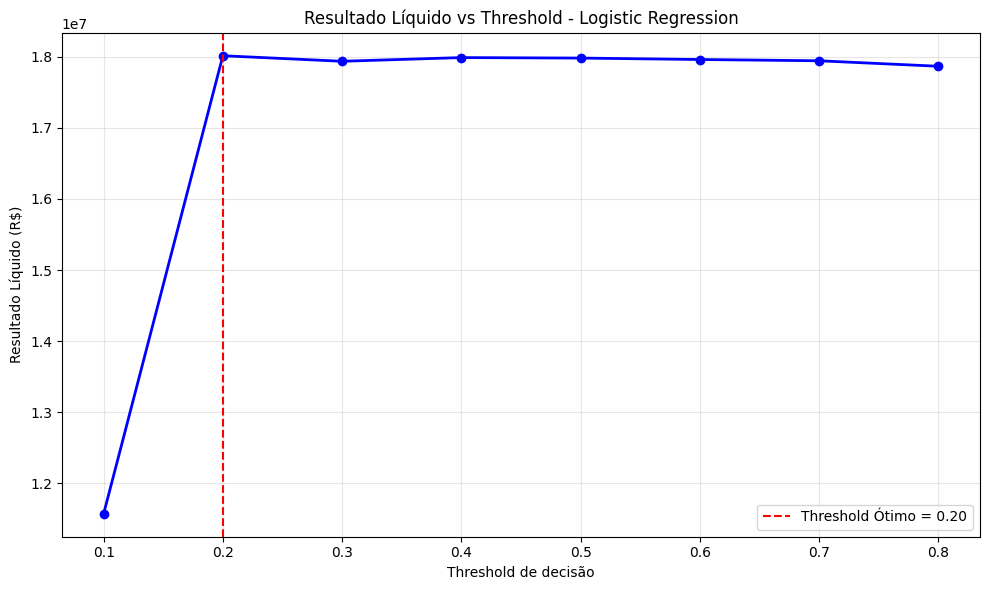

In [75]:
# Célula 11: Resultado Líquido vs Threshold
plt.figure(figsize=(10,6))
plt.plot(impacto_df['threshold'], impacto_df['resultado_liquido'], 'o-', color='blue', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Threshold Ótimo = {best_threshold:.2f}')
plt.xlabel("Threshold de decisão")
plt.ylabel("Resultado Líquido (R$)")
plt.title("Resultado Líquido vs Threshold - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [87]:
# Célula 10: Salvar Modelo e Resultados
print("\n" + "=" * 80)
print("💾 SALVANDO MODELO E RESULTADOS")
print("=" * 80)

# Criar dataframe de importância das features (coeficientes da regressão logística)
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

# Salvar modelo treinado
model_path = '../models/logistic_regression_baseline.pkl'
joblib.dump(model, model_path)
print(f"✅ Modelo salvo em: {model_path}")

# Salvar métricas principais
results = {
    'model_name': 'Logistic Regression (Baseline)',
    'train_accuracy': train_metrics['accuracy'],
    'train_f1': train_metrics['f1'],
    'train_auc': train_metrics['auc'],
    'test_accuracy': test_metrics['accuracy'],
    'test_f1': test_metrics['f1'],
    'test_auc': test_metrics['auc'],
    'optimal_threshold': optimal_threshold,
    'n_features': X_train.shape[1]
}

results_df = pd.DataFrame([results])
results_path = '../reports/model_results.csv'
results_df.to_csv(results_path, index=False)
print(f"✅ Resultados salvos em: {results_path}")

# Salvar importância das features (coeficientes)
# Certifique-se de que 'coefficients' já foi criado anteriormente
features_path = '../reports/lr_feature_importance.csv'
coefficients.head(30).to_csv(features_path, index=False)
print(f"✅ Importância das features salva em: {features_path}")

# Salvar impacto financeiro por threshold
impacto_path = '../reports/impacto_financeiro_thresholds.csv'
impacto_df.to_csv(impacto_path, index=False) 
print(f"✅ Impacto financeiro por threshold salvo em: {impacto_path}")


💾 SALVANDO MODELO E RESULTADOS
✅ Modelo salvo em: ../models/logistic_regression_baseline.pkl
✅ Resultados salvos em: ../reports/model_results.csv
✅ Importância das features salva em: ../reports/lr_feature_importance.csv
✅ Impacto financeiro por threshold salvo em: ../reports/impacto_financeiro_thresholds.csv


Threshold 0.10 → ótimo do ponto de vista estatístico (F1).

Threshold 0.20 → ótimo do ponto de vista financeiro (resultado líquido).

O que eu salvei: o threshold 0.20

In [86]:
# Célula 11: Resumo Final
print("\n" + "=" * 80)
print("🎉 BASELINE MODEL COMPLETO!")
print("=" * 80)

print(f"\n📊 RESUMO DE PERFORMANCE:")

print(f"\n   TRAIN:")
print(f"      Accuracy: {train_metrics['accuracy']:.4f}")
print(f"      F1-Score: {train_metrics['f1']:.4f}")
print(f"      AUC-ROC:  {train_metrics['auc']:.4f}")

print(f"\n   TEST:")
print(f"      Accuracy: {test_metrics['accuracy']:.4f}")
print(f"      F1-Score: {test_metrics['f1']:.4f}")
print(f"      AUC-ROC:  {test_metrics['auc']:.4f}")

# Verificar overfitting
overfit_accuracy = train_metrics['accuracy'] - test_metrics['accuracy']
overfit_auc = train_metrics['auc'] - test_metrics['auc']

print(f"\n🔍 ANÁLISE DE OVERFITTING:")
print(f"   Diferença Accuracy: {overfit_accuracy:.4f}")
print(f"   Diferença AUC:      {overfit_auc:.4f}")

if overfit_auc < 0.05:
    print(f"   ✅ Sem overfitting significativo!")
elif overfit_auc < 0.1:
    print(f"   ⚠️ Overfitting leve")
else:
    print(f"   ❌ Overfitting detectado")

print(f"\n🎚️ THRESHOLD ÓTIMO:")
print(f"   • Estatístico (F1 máximo): {optimal_threshold_f1:.2f}")
print(f"   • Financeiro (resultado líquido máximo): {optimal_threshold_financeiro:.2f}")

print(f"\n💡 INSIGHTS:")
print(f"   • Modelo baseline estabelecido")
print(f"   • AUC {test_metrics['auc']:.3f} é a referência a superar")
print(f"   • Threshold financeiro ({optimal_threshold:.2f}) maximiza resultado líquido")
print(f"   • Top features identificadas para análise")

print(f"\n🎯 PRÓXIMOS PASSOS:")
print(f"   • Dia 17: Random Forest (melhorar performance)")
print(f"   • Dia 18: XGBoost/LightGBM (modelos avançados)")
print(f"   • Objetivo: AUC > {test_metrics['auc'] + 0.05:.3f}")



🎉 BASELINE MODEL COMPLETO!

📊 RESUMO DE PERFORMANCE:

   TRAIN:
      Accuracy: 0.9331
      F1-Score: 0.0235
      AUC-ROC:  0.7105

   TEST:
      Accuracy: 0.9336
      F1-Score: 0.0351
      AUC-ROC:  0.7184

🔍 ANÁLISE DE OVERFITTING:
   Diferença Accuracy: -0.0005
   Diferença AUC:      -0.0079
   ✅ Sem overfitting significativo!

🎚️ THRESHOLD ÓTIMO:
   • Estatístico (F1 máximo): 0.10
   • Financeiro (resultado líquido máximo): 0.20

💡 INSIGHTS:
   • Modelo baseline estabelecido
   • AUC 0.718 é a referência a superar
   • Threshold financeiro (0.10) maximiza resultado líquido
   • Top features identificadas para análise

🎯 PRÓXIMOS PASSOS:
   • Dia 17: Random Forest (melhorar performance)
   • Dia 18: XGBoost/LightGBM (modelos avançados)
   • Objetivo: AUC > 0.768
